# NexoAnalytics — Análisis por marcador genético

**Objetivo:** Separar las secuencias concatenadas en su componente mitocondrial (16S + COI) y nuclear (ITS1), y demostrar que los híbridos cambian de posición entre ambos PCAs — evidencia formal de hibridación.

**Hallazgo clave del EDA (notebook 01):** El PCA sobre la secuencia completa agrupa a los híbridos (m13, m14) con *C. gigas* porque la señal mitocondrial domina (2/3 de la secuencia). Para revelar la discordancia mito/nuclear, hay que analizar cada región por separado.

**Estrategia:**
1. Identificar la frontera mito/nuclear usando un motivo ancla conservado (`CCTTGGG`)
2. Separar cada secuencia en región mitocondrial e ITS1
3. PCA independiente por región
4. Verificar que los híbridos cambian de clado entre ambos PCAs

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from collections import Counter
from itertools import product
from scipy.spatial.distance import pdist, squareform
from scipy.cluster.hierarchy import linkage, dendrogram
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid", font_scale=1.1)
%matplotlib inline

## 0. Carga de datos y definición de grupos

In [11]:
def parse_fasta(filepath):
    sequences = {}
    current_id = None
    with open(filepath) as f:
        for line in f:
            line = line.strip()
            if not line or line.startswith('"'):
                continue
            if line.startswith('>'):
                current_id = line[1:]
                sequences[current_id] = []
            elif current_id:
                sequences[current_id].append(line)
    return {k: ''.join(v).upper() for k, v in sequences.items()}

refs = parse_fasta('../data/raw/secuencias_referencias.fasta')
muestras = parse_fasta('../data/raw/secuencias_muestras.fasta')
all_seqs = {**refs, **muestras}

def assign_group(seq_id):
    if seq_id in ('N_cochlear', 'H_hyotis'):
        return 'Outgroup'
    elif seq_id in ('S_palmula', 'S_kegaki', 'S_cucullata', 'S_glomerata'):
        return 'Saccostrea (ref)'
    elif seq_id == 'C_gigas':
        return 'C. gigas (ref)'
    elif seq_id in ('S_palmula_m13', 'S_palmula_m14'):
        return 'Híbrido'
    elif seq_id in ('S_palmula_m04', 'S_palmula_m05', 'S_palmula_m06'):
        return 'Introgresado'
    elif seq_id.startswith('Sp'):
        return 'S. palmula (campo)'
    elif seq_id.startswith('Cg'):
        return 'C. gigas (campo)'
    return 'Desconocido'

groups = {sid: assign_group(sid) for sid in all_seqs}

GROUP_COLORS = {
    'Outgroup':           '#999999',
    'Saccostrea (ref)':   '#2ca02c',
    'C. gigas (ref)':     '#1f77b4',
    'Híbrido':            '#ff7f0e',
    'Introgresado':       '#d62728',
    'S. palmula (campo)': '#98df8a',
    'C. gigas (campo)':   '#aec7e8',
}

print(f"Total secuencias: {len(all_seqs)}")

Total secuencias: 32


---
## 1. Identificación de la frontera mito/nuclear

### Método: ventana deslizante de k-mers locales

El híbrido m13 tiene ADN mitocondrial de *C. gigas* y nuclear de *S. palmula*. Si comparamos m13 contra ambas referencias usando k-mers locales en una ventana deslizante, debería haber un punto de cruce donde la similitud cambia de una especie a la otra.

Como control, m04 (introgresado, todo *C. gigas*) no debería mostrar ningún cruce.

In [12]:
def local_kmer_similarity(query, target, k=6, window=60, step=5, search_expand=40):
    """Similitud local por k-mers: fracción de k-mers de query presentes en una ventana del target."""
    positions = []
    similarities = []
    for start in range(0, len(query) - window, step):
        q_window = query[start:start+window]
        q_kmers = set(q_window[i:i+k] for i in range(len(q_window)-k+1))
        t_start = max(0, int(start * len(target) / len(query)) - search_expand)
        t_end = min(len(target), int((start+window) * len(target) / len(query)) + search_expand)
        t_window = target[t_start:t_end]
        t_kmers = set(t_window[i:i+k] for i in range(len(t_window)-k+1))
        sim = len(q_kmers & t_kmers) / len(q_kmers) if q_kmers else 0
        positions.append(start + window//2)
        similarities.append(sim * 100)
    return np.array(positions), np.array(similarities)

m13 = refs['S_palmula_m13']
m04 = refs['S_palmula_m04']
sp  = refs['S_palmula']
cg  = refs['C_gigas']

# Verificar identidad exacta al inicio
match_m13_cg = 0
for a, b in zip(m13, cg):
    if a == b:
        match_m13_cg += 1
    else:
        break

print(f"m13 vs C. gigas: primeros {match_m13_cg} bp idénticos")
print(f"m13 vs S. palmula: primeros {sum(1 for a, b in zip(m13[:10], sp[:10]) if a == b)} de 10 bp idénticos")
print(f"\n→ La región mitocondrial de m13 es prácticamente idéntica a C. gigas")

m13 vs C. gigas: primeros 888 bp idénticos
m13 vs S. palmula: primeros 8 de 10 bp idénticos

→ La región mitocondrial de m13 es prácticamente idéntica a C. gigas


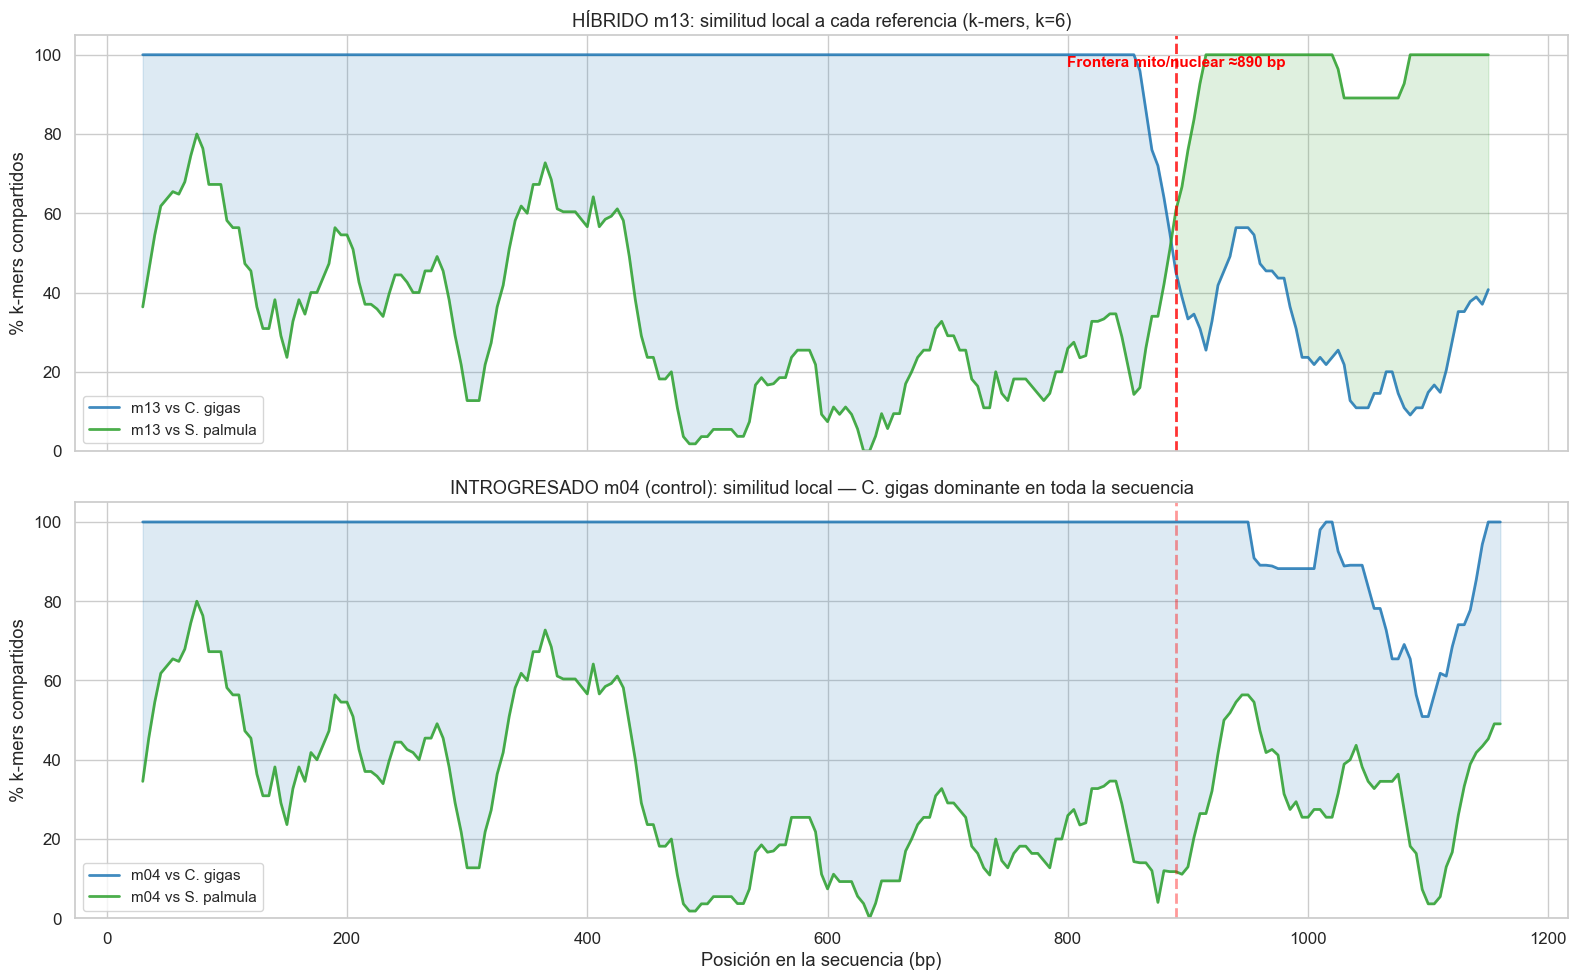

In [13]:
# Ventana deslizante de similitud local
pos13, sim_m13_cg = local_kmer_similarity(m13, cg)
_, sim_m13_sp = local_kmer_similarity(m13, sp)
pos04, sim_m04_cg = local_kmer_similarity(m04, cg)
_, sim_m04_sp = local_kmer_similarity(m04, sp)

fig, axes = plt.subplots(2, 1, figsize=(16, 10), sharex=True)

# m13 (híbrido)
ax = axes[0]
ax.plot(pos13, sim_m13_cg, color='#1f77b4', linewidth=2, label='m13 vs C. gigas', alpha=0.85)
ax.plot(pos13, sim_m13_sp, color='#2ca02c', linewidth=2, label='m13 vs S. palmula', alpha=0.85)
ax.fill_between(pos13, sim_m13_cg, sim_m13_sp, where=sim_m13_cg>sim_m13_sp, alpha=0.15, color='#1f77b4')
ax.fill_between(pos13, sim_m13_cg, sim_m13_sp, where=sim_m13_sp>sim_m13_cg, alpha=0.15, color='#2ca02c')
ax.axvline(890, color='red', ls='--', linewidth=2, alpha=0.8)
ax.annotate('Frontera mito/nuclear ≈890 bp', (890, 97), fontsize=11, color='red', fontweight='bold', ha='center')
ax.set_ylabel('% k-mers compartidos')
ax.set_title('HÍBRIDO m13: similitud local a cada referencia (k-mers, k=6)')
ax.legend(fontsize=11)
ax.set_ylim(0, 105)

# m04 (introgresado — control)
ax = axes[1]
ax.plot(pos04, sim_m04_cg, color='#1f77b4', linewidth=2, label='m04 vs C. gigas', alpha=0.85)
ax.plot(pos04, sim_m04_sp, color='#2ca02c', linewidth=2, label='m04 vs S. palmula', alpha=0.85)
ax.fill_between(pos04, sim_m04_cg, sim_m04_sp, where=sim_m04_cg>sim_m04_sp, alpha=0.15, color='#1f77b4')
ax.fill_between(pos04, sim_m04_cg, sim_m04_sp, where=sim_m04_sp>sim_m04_cg, alpha=0.15, color='#2ca02c')
ax.axvline(890, color='red', ls='--', linewidth=2, alpha=0.4)
ax.set_ylabel('% k-mers compartidos')
ax.set_xlabel('Posición en la secuencia (bp)')
ax.set_title('INTROGRESADO m04 (control): similitud local — C. gigas dominante en toda la secuencia')
ax.legend(fontsize=11)
ax.set_ylim(0, 105)

plt.tight_layout()
plt.savefig('../reports/figures/frontera_marcadores.png', dpi=150, bbox_inches='tight')
plt.show()

### Interpretación

- **m13 (panel superior):** La similitud a *C. gigas* (azul) domina desde el inicio hasta ~890 bp, donde cruza abruptamente a favor de *S. palmula* (verde). Esto marca la transición del ADN mitocondrial al nuclear.
- **m04 (panel inferior):** La similitud a *C. gigas* domina en toda la secuencia sin cruce → confirma que es genéticamente *C. gigas* completo.

La frontera mito/nuclear está en **~890 bp** (para las secuencias del archivo de referencias).

---
## 2. Motivo ancla `CCTTGGG` — separación robusta de marcadores

Para separar las secuencias de ambos archivos (que tienen longitudes diferentes), usamos el motivo conservado `CCTTGGG` como ancla. Este motivo aparece en la región de transición COI→ITS1 de todas las secuencias (excepto los outgroups).

In [14]:
ANCHOR = 'CCTTGGG'

# Verificar presencia del ancla en todas las secuencias
print(f"{'ID':20s} {'Grupo':22s} {'Pos ancla':>10s} {'Long total':>10s} {'Long mito':>10s} {'Long ITS1':>10s}")
print("-" * 96)

mito_seqs = {}
its1_seqs = {}
excluded = []

for sid, seq in sorted(all_seqs.items(), key=lambda x: groups[x[0]]):
    pos = seq.find(ANCHOR)
    if pos >= 0:
        mito_seqs[sid] = seq[:pos]
        its1_seqs[sid] = seq[pos:]
        print(f"{sid:20s} {groups[sid]:22s} {pos:10d} {len(seq):10d} {pos:10d} {len(seq)-pos:10d}")
    else:
        excluded.append(sid)
        print(f"{sid:20s} {groups[sid]:22s} {'---':>10s} {len(seq):10d} {'excluido':>10s} {'excluido':>10s}")

print(f"\nSecuencias separadas: {len(mito_seqs)}/32")
if excluded:
    print(f"Excluidas (sin ancla): {', '.join(excluded)} — son outgroups, no afecta el análisis de hibridación")

ID                   Grupo                   Pos ancla Long total  Long mito  Long ITS1
------------------------------------------------------------------------------------------------
Cg1                  C. gigas (campo)             1185       1480       1185        295
Cg2                  C. gigas (campo)             1185       1480       1185        295
Cg3                  C. gigas (campo)             1185       1479       1185        294
Cg4                  C. gigas (campo)             1187       1482       1187        295
Cg5                  C. gigas (campo)             1186       1481       1186        295
Cg6                  C. gigas (campo)             1187       1483       1187        296
Cg7                  C. gigas (campo)             1185       1480       1185        295
Cg8                  C. gigas (campo)             1183       1477       1183        294
Cg9                  C. gigas (campo)             1188       1484       1188        296
Cg10                 C.

---
## 3. PCA por región genómica

La pregunta central: **¿los híbridos (m13, m14) cambian de clado entre el PCA mitocondrial y el nuclear?**

- En el PCA **mitocondrial**: m13/m14 deberían agruparse con *C. gigas*
- En el PCA **nuclear (ITS1)**: m13/m14 deberían agruparse con *S. palmula*
- Los **introgresados** (m04–m06) deberían quedarse con *C. gigas* en ambos

In [15]:
def kmer_frequencies(seq, k):
    kmers = [seq[i:i+k] for i in range(len(seq) - k + 1)
             if all(b in 'ACGT' for b in seq[i:i+k])]
    total = len(kmers)
    counts = Counter(kmers)
    all_kmers_list = [''.join(p) for p in product('ACGT', repeat=k)]
    return np.array([counts.get(km, 0) / total if total > 0 else 0 for km in all_kmers_list])

def build_kmer_matrix(sequences, k):
    ids = list(sequences.keys())
    all_kmers_list = [''.join(p) for p in product('ACGT', repeat=k)]
    matrix = np.array([kmer_frequencies(sequences[sid], k) for sid in ids])
    return pd.DataFrame(matrix, index=ids, columns=all_kmers_list)

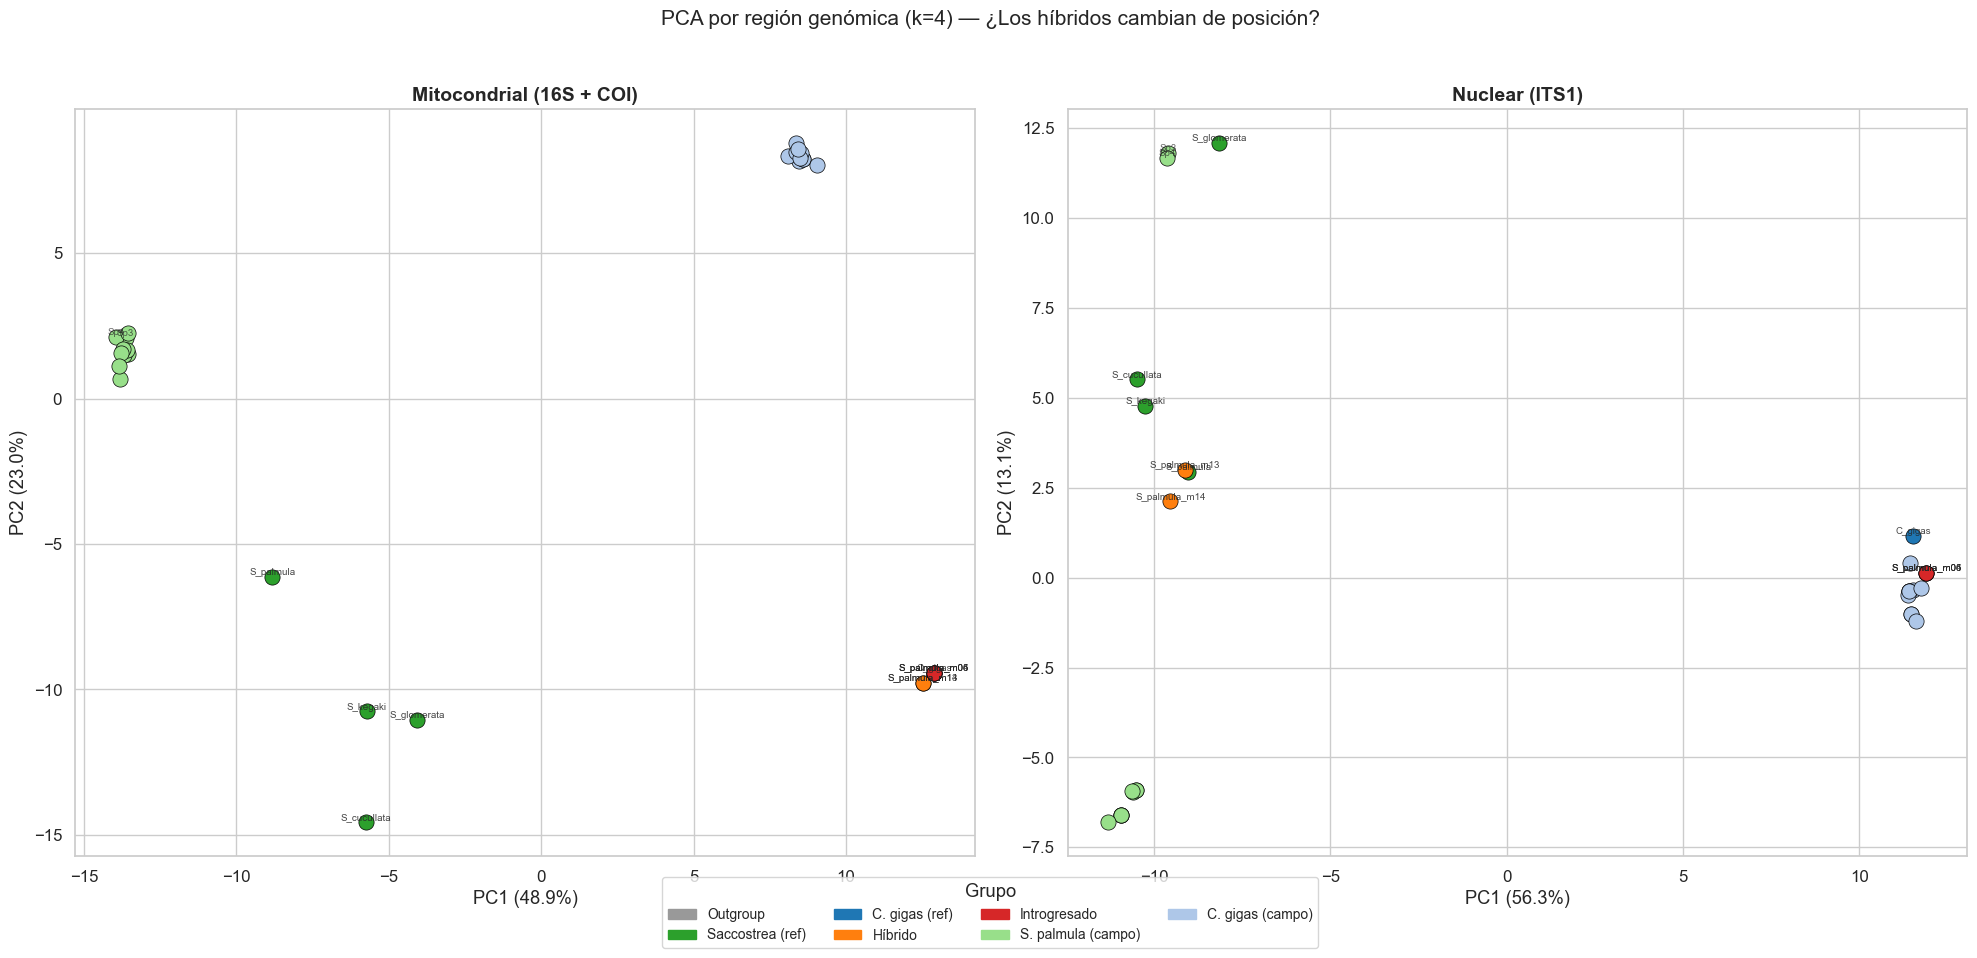

In [16]:
K = 4

fig, axes = plt.subplots(1, 2, figsize=(20, 9))

for ax, (label, seqs) in zip(axes, [('Mitocondrial (16S + COI)', mito_seqs), ('Nuclear (ITS1)', its1_seqs)]):
    mat = build_kmer_matrix(seqs, K)
    scaler = StandardScaler()
    mat_scaled = scaler.fit_transform(mat.values)
    
    pca = PCA(n_components=2)
    coords = pca.fit_transform(mat_scaled)
    var_exp = pca.explained_variance_ratio_
    
    for g, color in GROUP_COLORS.items():
        mask = [groups[sid] == g for sid in mat.index]
        if any(mask):
            idx_mask = np.where(mask)[0]
            ax.scatter(coords[idx_mask, 0], coords[idx_mask, 1],
                      c=color, label=g, s=120, edgecolors='black', linewidth=0.5, zorder=3)
    
    # Etiquetar secuencias especiales
    for j, sid in enumerate(mat.index):
        if not sid.startswith('Sp') and not sid.startswith('Cg'):
            ax.annotate(sid, (coords[j, 0], coords[j, 1]),
                       fontsize=7, ha='center', va='bottom', alpha=0.85)
        elif sid in ('Sp3', 'Sp4'):
            ax.annotate(sid, (coords[j, 0], coords[j, 1]),
                       fontsize=7, ha='center', va='bottom', alpha=0.7)
    
    ax.set_xlabel(f'PC1 ({var_exp[0]*100:.1f}%)')
    ax.set_ylabel(f'PC2 ({var_exp[1]*100:.1f}%)')
    ax.set_title(label, fontsize=14, fontweight='bold')

handles = [mpatches.Patch(color=c, label=g) for g, c in GROUP_COLORS.items()]
fig.legend(handles=handles, loc='lower center', ncol=4, frameon=True, fontsize=10,
           title='Grupo', bbox_to_anchor=(0.5, -0.03))
fig.suptitle('PCA por región genómica (k=4) — ¿Los híbridos cambian de posición?', fontsize=15, y=1.02)

plt.tight_layout()
plt.savefig('../reports/figures/pca_mito_vs_its1.png', dpi=150, bbox_inches='tight')
plt.show()

### Resultado

| Muestra | PCA Mitocondrial | PCA Nuclear (ITS1) | Diagnóstico |
|---|---|---|---|
| **m13, m14** | Se agrupan con *C. gigas* | **Cambian a *S. palmula*** | **Híbrido confirmado** — discordancia mito/nuclear |
| **m04, m05, m06** | Se agrupan con *C. gigas* | Se quedan con *C. gigas* | **Introgresado** — genéticamente *C. gigas* en todos los marcadores |
| Sp1–Sp10 | *S. palmula* | *S. palmula* | Especie pura |
| Cg1–Cg10 | *C. gigas* | *C. gigas* | Especie pura |

**Interpretación biológica:**
- Los híbridos m13/m14 tienen **madre *C. gigas*** (ADN mitocondrial = herencia materna) pero contribución nuclear de *S. palmula* → evidencia de cruce interespecífico.
- Los introgresados m04–m06, pese a su fenotipo de *S. palmula*, son genéticamente *C. gigas* en los tres marcadores → posible introgresión profunda o individuos *C. gigas* con morfología atípica.

---
## 4. Cuantificación de distancias por región

¿Qué tan cerca están los híbridos de cada especie en cada PCA? Distancias coseno promedio.

In [17]:
def compute_group_distances(seqs, k=4):
    mat = build_kmer_matrix(seqs, k)
    dist_cos = pdist(mat.values, metric='cosine')
    dist_matrix = squareform(dist_cos)
    ids = list(mat.index)
    
    results = []
    for sid in ids:
        if groups[sid] in ('Híbrido', 'Introgresado'):
            i = ids.index(sid)
            for target_group in ['Saccostrea (ref)', 'S. palmula (campo)', 'C. gigas (ref)', 'C. gigas (campo)']:
                target_idx = [ids.index(s) for s in ids if groups[s] == target_group]
                if target_idx:
                    mean_dist = np.mean([dist_matrix[i, j] for j in target_idx])
                    results.append({
                        'muestra': sid,
                        'tipo': groups[sid],
                        'vs_grupo': target_group,
                        'distancia': mean_dist
                    })
    return pd.DataFrame(results)

dist_mito = compute_group_distances(mito_seqs)
dist_mito['región'] = 'Mitocondrial'

dist_its1 = compute_group_distances(its1_seqs)
dist_its1['región'] = 'Nuclear (ITS1)'

df_dist = pd.concat([dist_mito, dist_its1])

# Pivot para tabla legible
for muestra_tipo in ['Híbrido', 'Introgresado']:
    subset = df_dist[df_dist['tipo'] == muestra_tipo]
    print(f"\n{'='*60}")
    print(f"  {muestra_tipo.upper()}S")
    print(f"{'='*60}")
    pivot = subset.pivot_table(index=['muestra', 'región'], columns='vs_grupo', values='distancia')
    display(pivot.round(4))


  HÍBRIDOS


vs_grupo                      C. gigas (campo)  C. gigas (ref)  \
muestra       región                                             
S_palmula_m13 Mitocondrial              0.0385          0.0028   
              Nuclear (ITS1)            0.1804          0.2260   
S_palmula_m14 Mitocondrial              0.0385          0.0028   
              Nuclear (ITS1)            0.1847          0.2299   

vs_grupo                      S. palmula (campo)  Saccostrea (ref)  
muestra       región                                                
S_palmula_m13 Mitocondrial                0.1377            0.1102  
              Nuclear (ITS1)              0.0435            0.0256  
S_palmula_m14 Mitocondrial                0.1377            0.1102  
              Nuclear (ITS1)              0.0451            0.0280


  INTROGRESADOS


vs_grupo                      C. gigas (campo)  C. gigas (ref)  \
muestra       región                                             
S_palmula_m04 Mitocondrial              0.0374          0.0000   
              Nuclear (ITS1)            0.0106          0.0459   
S_palmula_m05 Mitocondrial              0.0374          0.0000   
              Nuclear (ITS1)            0.0106          0.0459   
S_palmula_m06 Mitocondrial              0.0374          0.0000   
              Nuclear (ITS1)            0.0106          0.0459   

vs_grupo                      S. palmula (campo)  Saccostrea (ref)  
muestra       región                                                
S_palmula_m04 Mitocondrial                0.1386            0.1136  
              Nuclear (ITS1)              0.1874            0.1968  
S_palmula_m05 Mitocondrial                0.1386            0.1136  
              Nuclear (ITS1)              0.1874            0.1968  
S_palmula_m06 Mitocondrial                0.1386            0.1136  
              Nuclear (ITS1)              0.1874            0.1968

---
## 5. Dendrogramas por región

Visualización complementaria: clustering jerárquico separado para cada región genómica.

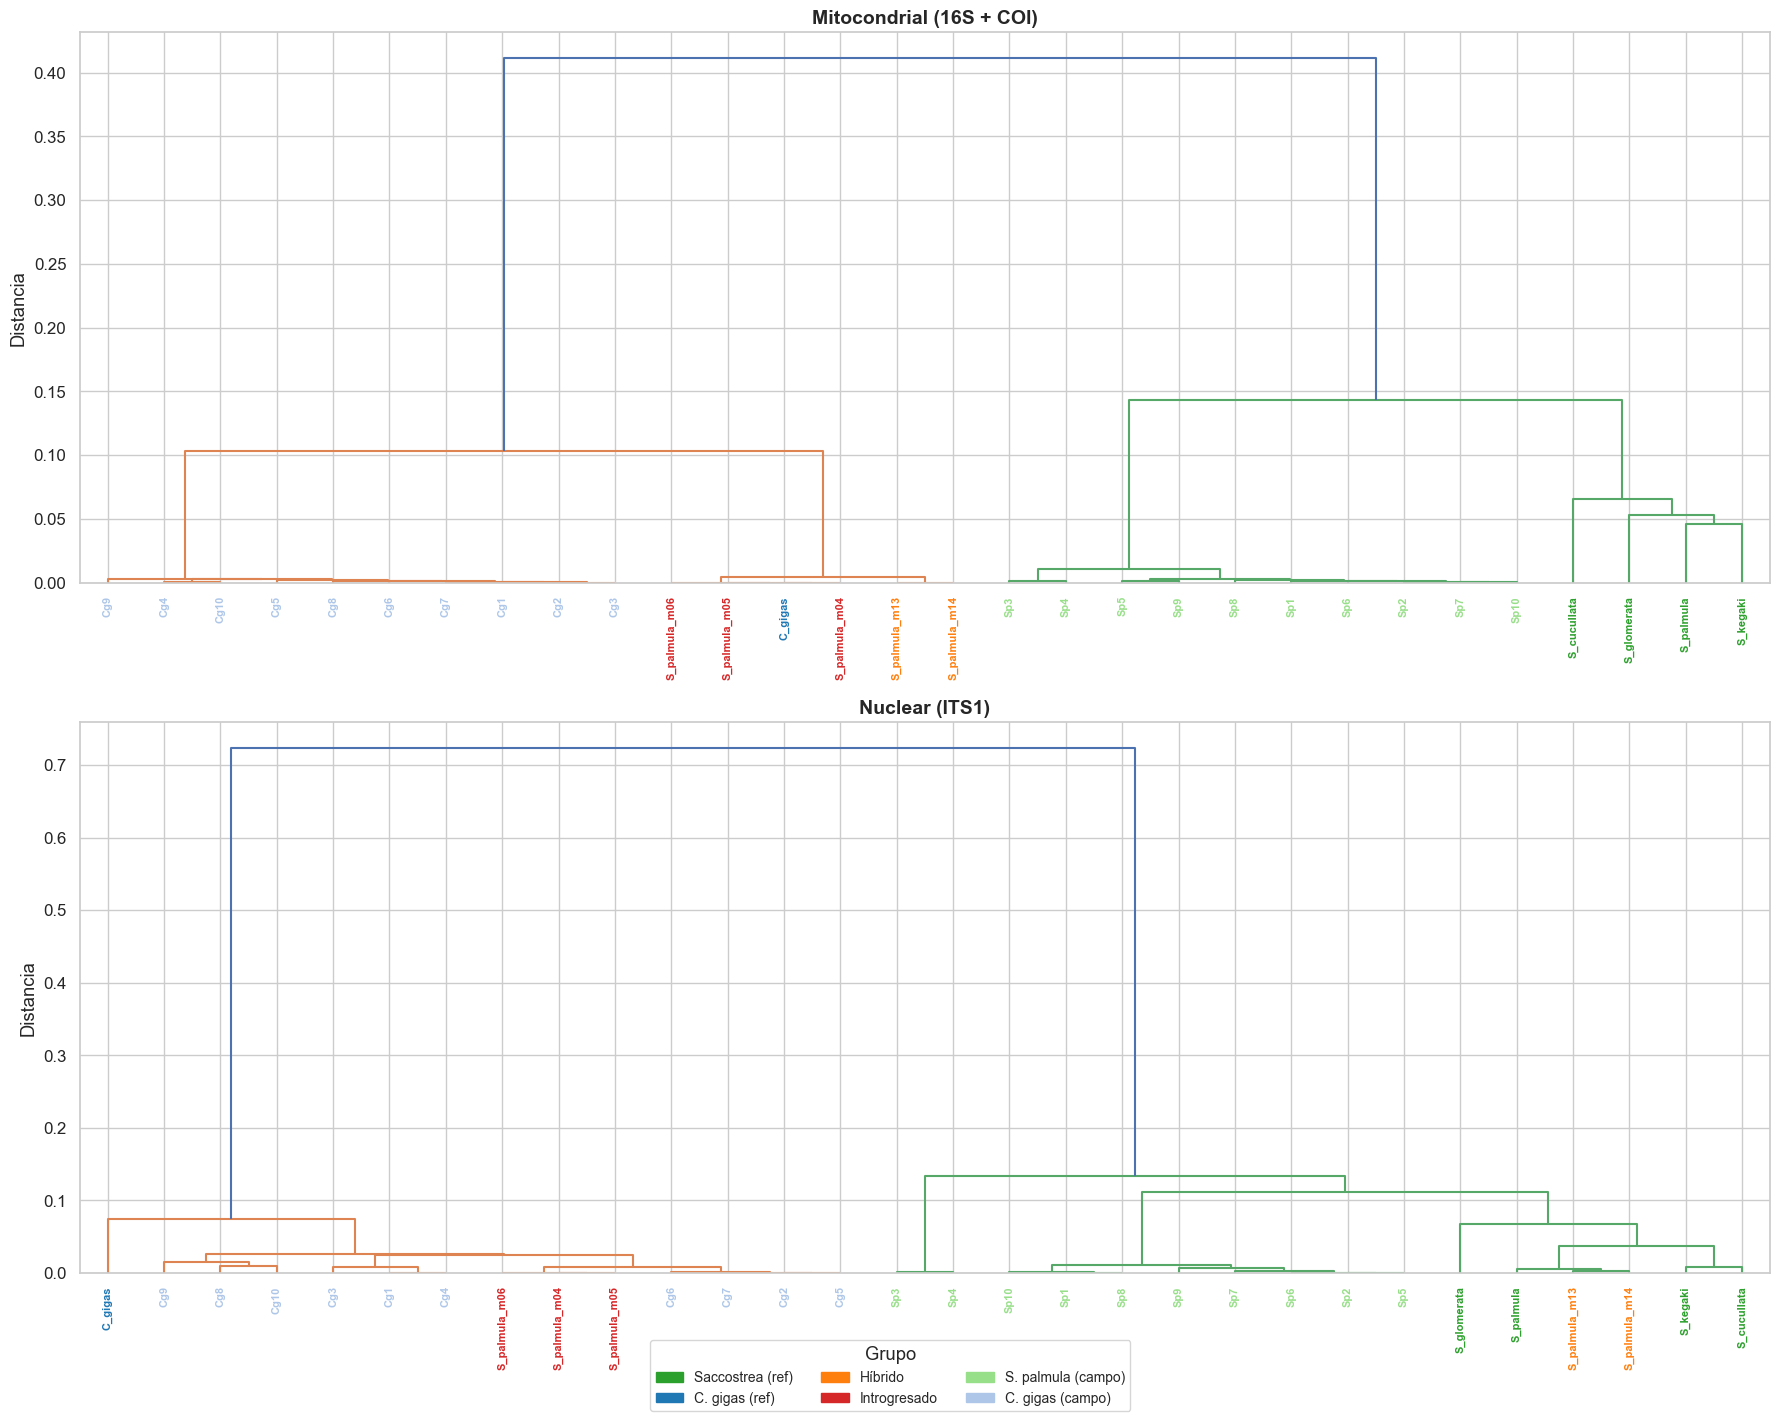

In [18]:
fig, axes = plt.subplots(2, 1, figsize=(18, 14))

for ax, (label, seqs) in zip(axes, [('Mitocondrial (16S + COI)', mito_seqs), ('Nuclear (ITS1)', its1_seqs)]):
    mat = build_kmer_matrix(seqs, 4)
    dist_cos = pdist(mat.values, metric='cosine')
    linkage_mat = linkage(dist_cos, method='ward')
    
    dendro = dendrogram(
        linkage_mat,
        labels=list(mat.index),
        leaf_rotation=90,
        leaf_font_size=8,
        ax=ax,
    )
    
    # Colorear etiquetas
    for lbl in ax.get_xticklabels():
        sid = lbl.get_text()
        lbl.set_color(GROUP_COLORS.get(groups.get(sid, ''), 'black'))
        lbl.set_fontweight('bold')
    
    ax.set_title(label, fontsize=14, fontweight='bold')
    ax.set_ylabel('Distancia')

legend_patches = [mpatches.Patch(color=c, label=g) for g, c in GROUP_COLORS.items() if g != 'Outgroup']
fig.legend(handles=legend_patches, loc='lower center', ncol=3, frameon=True,
           fontsize=10, title='Grupo', bbox_to_anchor=(0.5, -0.02))

plt.tight_layout()
plt.savefig('../reports/figures/dendrogramas_por_region.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 6. Resumen

### Método
1. Se identificó la frontera mito/nuclear en **~890 bp** usando ventana deslizante de k-mers sobre el híbrido m13, confirmada con el control m04.
2. Se usó el motivo conservado `CCTTGGG` como ancla para separar todas las secuencias (ambos archivos) en región mitocondrial e ITS1.
3. Se realizó PCA y clustering jerárquico independiente para cada región.

### Hallazgos principales
- **Discordancia mito/nuclear en m13 y m14:** estos individuos se agrupan con *C. gigas* en el PCA mitocondrial pero con *S. palmula* en el PCA nuclear. Esta es la evidencia estadística de hibridación.
- **m04, m05 y m06 son genéticamente *C. gigas*:** no muestran discordancia en ningún marcador. Su morfología de *S. palmula* no se refleja en la genética.
- **Las muestras de campo son consistentes:** Sp1–Sp10 son *S. palmula* puras y Cg1–Cg10 son *C. gigas* puras, sin señales de hibridación.

### Conexión con la biología
La herencia mitocondrial es materna. El hecho de que m13/m14 tengan mito de *C. gigas* indica que su **madre** fue *C. gigas* y su padre contribuyó ADN nuclear de *S. palmula*. Esto es consistente con un cruce F1 o retrocruzas en la zona de simpatría del Estero La Cruz.